# Modelos de marea — Ría de Foz

## 🌊 Modelos disponibles

### **Funcionando actualmente:**
- ✅ **GOT4.10** (Global Ocean Tide, GSFC) — Sin credenciales necesarias
- ✅ **CMEMS** (Copernicus Marine) — Acceso mediante `copernicusmarine`

### **Temporalmente no disponibles:**
- ⚠️ **FES2014** (AVISO) — Requiere credenciales, sitio AVISO caído
- ⚠️ **FES2022** (AVISO) — Requiere credenciales, sitio AVISO caído

**Nota**: El sitio de AVISO (https://www.aviso.altimetry.fr/) está temporalmente no disponible. Los modelos FES requieren registro y descarga desde ese sitio. Cuando vuelva a estar disponible, puedes añadir `"FES2014"` o `"FES2022"` a `pytmd_models_to_test` y configurar las variables de entorno `PYTMD_FES_USER` y `PYTMD_FES_PASSWORD`.

---

## 📊 Análisis de calidad de distribuciones mareales

Este notebook evalúa la calidad de las distribuciones de altura de marea para determinar su aptitud en el **método waterline** de reconstrucción batimétrica.

In [16]:
import sys, time
sys.path.insert(0, r"C:\Users\Jorge\sketch_fitton\Intertidal_analysis")

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from intertidal.tidemodel import PyTMDTideModel, CopernicusTideModel
import numpy as np

LAT, LON = 43.593075, -7.225533

# Muestreo cada 2 horas para capturar bien las oscilaciones
dates = pd.date_range("2024-01-01", "2024-06-30 23:00", freq="2h")  
print(f"{len(dates)} mediciones (cada 2h): {dates[0]} → {dates[-1]}")


2184 mediciones (cada 2h): 2024-01-01 00:00:00 → 2024-06-30 22:00:00


In [17]:
# ────────────────────────────────────────────────────────────────────
# Configurar modelos de marea a comparar
# ────────────────────────────────────────────────────────────────────

# Modelos PyTMD a probar (añadir más aquí)
# ⚠️  FES2014/FES2022: Requieren credenciales AVISO (https://www.aviso.altimetry.fr/)
#     Si el sitio de AVISO está caído, solo usa GOT4.10
pytmd_models_to_test = ["GOT4.10"]  # Añade "FES2014", "FES2022" cuando AVISO esté disponible

# Diccionario para almacenar todos los modelos
tide_models = {}

# Cargar modelos PyTMD
for model_name in pytmd_models_to_test:
    try:
        print(f"\n{'='*60}")
        print(f"Configurando modelo PyTMD: {model_name}")
        print(f"{'='*60}")
        tide_models[model_name] = PyTMDTideModel(
            model_name=model_name, 
            directory="./tide_models", 
            box_size=2.0, 
            resolution=0.1
        )
        print(f"✓ {model_name} configurado correctamente")
    except Exception as e:
        print(f"✗ Error configurando {model_name}: {e}")
        print(f"  Saltando modelo {model_name}...")

# Cargar modelo CMEMS
print(f"\n{'='*60}")
print(f"Configurando modelo CMEMS")
print(f"{'='*60}")
tide_models["CMEMS"] = CopernicusTideModel()
print(f"✓ CMEMS configurado correctamente")

print(f"\n{'='*60}")
print(f"RESUMEN: {len(tide_models)} modelos configurados")
print(f"{'='*60}")
for model in tide_models.keys():
    print(f"  • {model}")



Configurando modelo PyTMD: GOT4.10
Modelo GOT4.10 ya descargado
✓ GOT4.10 configurado correctamente

Configurando modelo CMEMS


INFO - 2026-07-07T10:37:01Z - Using existing credentials from C:\Users\Jorge\.copernicusmarine\.copernicusmarine-credentials. Use --force-overwrite combined with credentials (specified by arguments, netrc file or environment variables) to always overwrite.
INFO:copernicusmarine:Using existing credentials from C:\Users\Jorge\.copernicusmarine\.copernicusmarine-credentials. Use --force-overwrite combined with credentials (specified by arguments, netrc file or environment variables) to always overwrite.


✓ CMEMS configurado correctamente

RESUMEN: 2 modelos configurados
  • GOT4.10
  • CMEMS


In [18]:
# ────────────────────────────────────────────────────────────────────
# Calcular mareas para distribución completa (referencia)
# ────────────────────────────────────────────────────────────────────
# Solo se usa como REFERENCIA para evaluar la cobertura de las fechas seleccionadas

print("Calculando alturas de marea para distribución completa (referencia)...")
print("Esto se usa solo para calcular el rango total contra el que comparar\n")

# Diccionario para almacenar resultados: {modelo: {fechas: valores}}
mareas_completas = {}

for model_name, model in tide_models.items():
    print(f"  • {model_name}...", end=" ")
    t0 = time.time()
    heights = model.get_tide_heights_batch(LAT, LON, [d.to_pydatetime() for d in dates])
    mareas_completas[model_name] = heights
    print(f"{len(heights)} valores en {time.time()-t0:.1f}s")

print(f"\n✓ Mareas de referencia calculadas para {len(tide_models)} modelos")


Calculando alturas de marea para distribución completa (referencia)...
Esto se usa solo para calcular el rango total contra el que comparar

  • GOT4.10... 2184 valores en 7.8s
  • CMEMS... 

INFO - 2026-07-07T10:37:11Z - Selected dataset version: "202511"
INFO:copernicusmarine:Selected dataset version: "202511"
INFO - 2026-07-07T10:37:11Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"


2184 valores en 5.6s

✓ Mareas de referencia calculadas para 2 modelos


## Análisis de mareas en horas de paso del satélite

Comparación de las alturas de marea durante los sobrevuelos de Sentinel-2 vs. la distribución completa cada 2h.

Se usan las **303 fechas válidas** del pipeline `foz_sentinel2_scl.ipynb` (`selected_dates_foz`) para el periodo 2015-2024. El flujo es: configuración → horas de sobrevuelo → alturas de marea en esas horas → distribución vertical con los límites analíticos (rango del periodo completo cada 2 h).


In [19]:
# ────────────────────────────────────────────────────────────────────
# Configuración del AOI de Foz (mismo que foz_sentinel2_scl.ipynb)
# ────────────────────────────────────────────────────────────────────
from intertidal.overpass import get_overpass_times

# Bounding box de la Ría de Foz
bbox_foz = {
    'west': -7.285,
    'south': 43.52,
    'east': -7.205,
    'north': 43.59
}

# Periodo: 2015-2024 (10 años para análisis multi-año)
time_extent_10years = ["2015-01-01", "2024-12-31"]

# ────────────────────────────────────────────────────────────────────
# Fechas VÁLIDAS finales del pipeline foz_sentinel2_scl.ipynb (2015-2024)
# (variable `valid_scene_dates` — 303 fechas que superan el pipeline completo)
#   [ref] 275 fechas con ≤5% píxeles malos globales
#   [✓]    28 fechas recuperadas por el filtro de transición del estuario
# ────────────────────────────────────────────────────────────────────
selected_dates_foz = [
    # 2015 (5 fechas)
    "2015-07-25", "2015-08-04", "2015-08-17", "2015-10-23", "2015-11-12", "2015-11-15",
    # 2016 (18 fechas)
    "2016-01-11", "2016-03-14", "2016-04-30", "2016-07-09", "2016-07-19", "2016-07-22",
    "2016-08-01", "2016-08-18", "2016-08-21", "2016-09-07", "2016-10-07", "2016-10-10",
    "2016-11-16", "2016-12-29",
    # 2017 (32 fechas)
    "2017-01-08", "2017-01-25", "2017-02-17", "2017-03-09", "2017-03-16", "2017-04-08",
    "2017-04-13", "2017-04-23", "2017-04-28", "2017-05-30", "2017-06-07", "2017-06-14",
    "2017-06-17", "2017-07-02", "2017-07-17", "2017-08-03", "2017-08-11", "2017-08-13",
    "2017-08-16", "2017-08-21", "2017-09-02", "2017-09-05", "2017-10-02", "2017-10-07",
    "2017-10-10", "2017-10-12", "2017-10-20", "2017-10-27", "2017-11-14", "2017-11-16",
    "2017-11-19", "2017-11-26", "2017-12-21", "2017-12-24",
    # 2018 (31 fechas)
    "2018-01-18", "2018-01-28", "2018-02-12", "2018-02-17", "2018-02-22", "2018-02-24",
    "2018-04-03", "2018-05-15", "2018-06-14", "2018-06-17", "2018-06-24", "2018-07-12",
    "2018-08-06", "2018-08-11", "2018-08-21", "2018-08-26", "2018-08-31", "2018-09-02",
    "2018-09-10", "2018-09-17", "2018-09-20", "2018-09-22", "2018-09-25", "2018-10-02",
    "2018-10-05", "2018-10-10", "2018-10-12", "2018-10-17", "2018-10-25", "2018-11-14",
    "2018-11-16", "2018-11-19", "2018-12-09", "2018-12-26", "2018-12-31",
    # 2019 (30 fechas)
    "2019-01-03", "2019-01-05", "2019-02-12", "2019-02-14", "2019-02-19", "2019-02-24",
    "2019-03-11", "2019-03-16", "2019-03-26", "2019-03-29", "2019-03-31", "2019-04-08",
    "2019-04-13", "2019-04-20", "2019-05-03", "2019-05-13", "2019-05-25", "2019-05-28",
    "2019-05-30", "2019-07-12", "2019-07-24", "2019-07-29", "2019-08-03", "2019-08-13",
    "2019-08-16", "2019-08-21", "2019-09-02", "2019-09-07", "2019-09-12", "2019-10-07",
    "2019-10-10", "2019-10-25", "2019-11-16", "2019-11-29", "2019-12-04", "2019-12-26",
    "2019-12-29", "2019-12-31",
    # 2020 (32 fechas)
    "2020-01-05", "2020-01-15", "2020-01-25", "2020-01-28", "2020-02-07", "2020-02-19",
    "2020-02-24", "2020-03-10", "2020-03-18", "2020-03-25", "2020-03-28", "2020-04-04",
    "2020-05-07", "2020-05-17", "2020-05-19", "2020-05-27", "2020-05-29", "2020-06-01",
    "2020-07-03", "2020-07-18", "2020-07-26", "2020-08-05", "2020-09-04", "2020-09-16",
    "2020-09-29", "2020-10-16", "2020-10-29", "2020-11-13", "2020-11-18", "2020-11-20",
    "2020-11-30", "2020-12-28",
    # 2021 (34 fechas)
    "2021-01-12", "2021-01-22", "2021-02-13", "2021-02-23", "2021-03-15", "2021-03-25",
    "2021-03-28", "2021-04-02", "2021-04-04", "2021-04-07", "2021-04-09", "2021-04-12",
    "2021-04-17", "2021-05-19", "2021-05-29", "2021-07-01", "2021-07-16", "2021-07-26",
    "2021-08-10", "2021-08-12", "2021-09-04", "2021-09-11", "2021-10-06", "2021-10-11",
    "2021-10-19", "2021-11-10", "2021-11-13", "2021-11-18", "2021-11-20", "2021-11-30",
    "2021-12-13", "2021-12-18", "2021-12-30",
    # 2022 (30 fechas)
    "2022-01-12", "2022-01-14", "2022-01-17", "2022-01-19", "2022-01-22", "2022-01-24",
    "2022-01-27", "2022-02-06", "2022-02-08", "2022-03-18", "2022-03-23", "2022-04-02",
    "2022-04-09", "2022-06-18", "2022-06-28", "2022-07-01", "2022-07-08", "2022-07-11",
    "2022-07-23", "2022-07-31", "2022-08-20", "2022-09-09", "2022-09-19", "2022-09-21",
    "2022-10-04", "2022-11-03", "2022-11-13", "2022-11-23", "2022-11-25", "2022-12-10",
    # 2023 (58 fechas)
    "2023-01-02", "2023-01-09", "2023-02-01", "2023-02-03", "2023-02-06", "2023-02-08",
    "2023-02-11", "2023-02-16", "2023-03-05", "2023-03-10", "2023-03-15", "2023-03-20",
    "2023-03-28", "2023-04-02", "2023-04-17", "2023-04-19", "2023-04-27", "2023-04-29",
    "2023-05-07", "2023-05-17", "2023-05-29", "2023-06-11", "2023-06-13", "2023-06-28",
    "2023-07-01", "2023-07-18", "2023-07-21", "2023-07-23", "2023-07-26", "2023-07-31",
    "2023-08-05", "2023-08-07", "2023-08-10", "2023-08-17", "2023-09-14", "2023-09-24",
    "2023-09-26", "2023-10-09", "2023-10-21", "2023-11-15", "2023-11-23", "2023-12-13",
    "2023-12-18", "2023-12-25", "2023-12-30",
    # 2024 (38 fechas)
    "2024-01-07", "2024-01-14", "2024-01-19", "2024-01-24", "2024-02-03", "2024-02-06",
    "2024-02-16", "2024-03-04", "2024-03-12", "2024-03-14", "2024-04-01", "2024-04-21",
    "2024-05-08", "2024-05-11", "2024-05-28", "2024-06-02", "2024-07-12", "2024-07-22",
    "2024-07-30", "2024-08-04", "2024-08-11", "2024-08-14", "2024-08-16", "2024-08-19",
    "2024-08-26", "2024-09-15", "2024-09-18", "2024-09-23", "2024-09-28", "2024-10-13",
    "2024-10-23", "2024-11-02", "2024-11-07", "2024-11-29", "2024-12-07", "2024-12-14",
]

print("Configuración cargada:")
print(f"  AOI: Ría de Foz {bbox_foz}")
print(f"  Periodo: {time_extent_10years[0]} → {time_extent_10years[1]}")
print(f"  Fechas válidas del pipeline: {len(selected_dates_foz)}")
print(f"\n  Distribución por año:")
for year in range(2015, 2025):
    year_str = str(year)
    count = len([d for d in selected_dates_foz if d.startswith(year_str)])
    print(f"    {year}: {count:3d} fechas")


Configuración cargada:
  AOI: Ría de Foz {'west': -7.285, 'south': 43.52, 'east': -7.205, 'north': 43.59}
  Periodo: 2015-01-01 → 2024-12-31
  Fechas válidas del pipeline: 303

  Distribución por año:
    2015:   6 fechas
    2016:  14 fechas
    2017:  34 fechas
    2018:  35 fechas
    2019:  38 fechas
    2020:  32 fechas
    2021:  33 fechas
    2022:  30 fechas
    2023:  45 fechas
    2024:  36 fechas


In [20]:
# ────────────────────────────────────────────────────────────────────
# Obtener horas exactas de paso del satélite Sentinel-2 sobre Foz (2015-2024)
# ────────────────────────────────────────────────────────────────────
print("Consultando catálogo STAC para obtener horas de sobrevuelo...")
t0 = time.time()

overpass_dict = get_overpass_times(bbox_foz, time_extent_10years)

print(f"✓ Obtenidas {len(overpass_dict)} fechas con hora exacta en {time.time()-t0:.1f}s\n")

if not overpass_dict:
    raise RuntimeError(
        "get_overpass_times() devolvió 0 fechas. Revisa la conexión al catálogo STAC, "
        "el bounding box (bbox_foz) o el periodo (time_extent_10years). "
        "Sin escenas no se puede construir overpass_df."
    )

# Convertir a DataFrame para análisis (columnas explícitas para evitar
# KeyError si el diccionario estuviese vacío)
overpass_df = pd.DataFrame(
    [{"date_str": date_str, "datetime": dt} for date_str, dt in overpass_dict.items()],
    columns=["date_str", "datetime"],
).sort_values("datetime").reset_index(drop=True)

# Filtrar solo las fechas seleccionadas
selected_overpass_df = overpass_df[overpass_df["date_str"].isin(selected_dates_foz)].copy()

print(f"Total de sobrevuelos 2015-2024: {len(overpass_df)}")
print(f"Sobrevuelos en fechas seleccionadas: {len(selected_overpass_df)}")
print(f"\nPrimeros 5 sobrevuelos:")
for _, row in overpass_df.head().iterrows():
    print(f"  {row['datetime'].strftime('%Y-%m-%d %H:%M:%S')}")


Consultando catálogo STAC para obtener horas de sobrevuelo...
✓ Obtenidas 1230 fechas con hora exacta en 55.1s

Total de sobrevuelos 2015-2024: 1230
Sobrevuelos en fechas seleccionadas: 303

Primeros 5 sobrevuelos:
  2015-07-08 11:30:56
  2015-07-15 11:28:46
  2015-07-25 11:20:46
  2015-07-28 11:30:56
  2015-08-04 11:20:46


In [21]:
# ────────────────────────────────────────────────────────────────────
# Calcular alturas de marea en FECHAS SELECCIONADAS (303 fechas válidas)
# ────────────────────────────────────────────────────────────────────
# ESTAS son las que realmente nos importan para el modelado batimétrico

print("Calculando mareas en fechas seleccionadas (303 fechas válidas 2015-2024)...")
print("Estas son las observaciones reales disponibles para modelado\n")

# Diccionario: {modelo: alturas_en_fechas_seleccionadas}
mareas_seleccionadas = {}

for model_name, model in tide_models.items():
    print(f"  • {model_name}...", end=" ")
    t0 = time.time()
    heights = model.get_tide_heights_batch(LAT, LON, selected_overpass_df["datetime"].tolist())
    mareas_seleccionadas[model_name] = heights
    rango = max(heights) - min(heights)
    print(f"{len(heights)} valores en {time.time()-t0:.1f}s (rango: {rango:.2f} m)")

# Añadir al DataFrame de fechas seleccionadas
for model_name, heights in mareas_seleccionadas.items():
    selected_overpass_df[model_name] = heights

print(f"\n✓ Mareas calculadas para {len(tide_models)} modelos")
print(f"\nEstadísticas de las fechas seleccionadas:")
for model_name, heights in mareas_seleccionadas.items():
    print(f"  {model_name:12s} → min: {min(heights):+.2f} m, max: {max(heights):+.2f} m, rango: {max(heights)-min(heights):.2f} m")


Calculando mareas en fechas seleccionadas (303 fechas válidas 2015-2024)...
Estas son las observaciones reales disponibles para modelado

  • GOT4.10... 

303 valores en 7.7s (rango: 3.41 m)
  • CMEMS... 

INFO - 2026-07-07T10:38:20Z - Selected dataset version: "202511"
INFO:copernicusmarine:Selected dataset version: "202511"
INFO - 2026-07-07T10:38:20Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"


303 valores en 6.3s (rango: 3.40 m)

✓ Mareas calculadas para 2 modelos

Estadísticas de las fechas seleccionadas:
  GOT4.10      → min: -2.06 m, max: +1.35 m, rango: 3.41 m
  CMEMS        → min: -2.35 m, max: +1.06 m, rango: 3.40 m


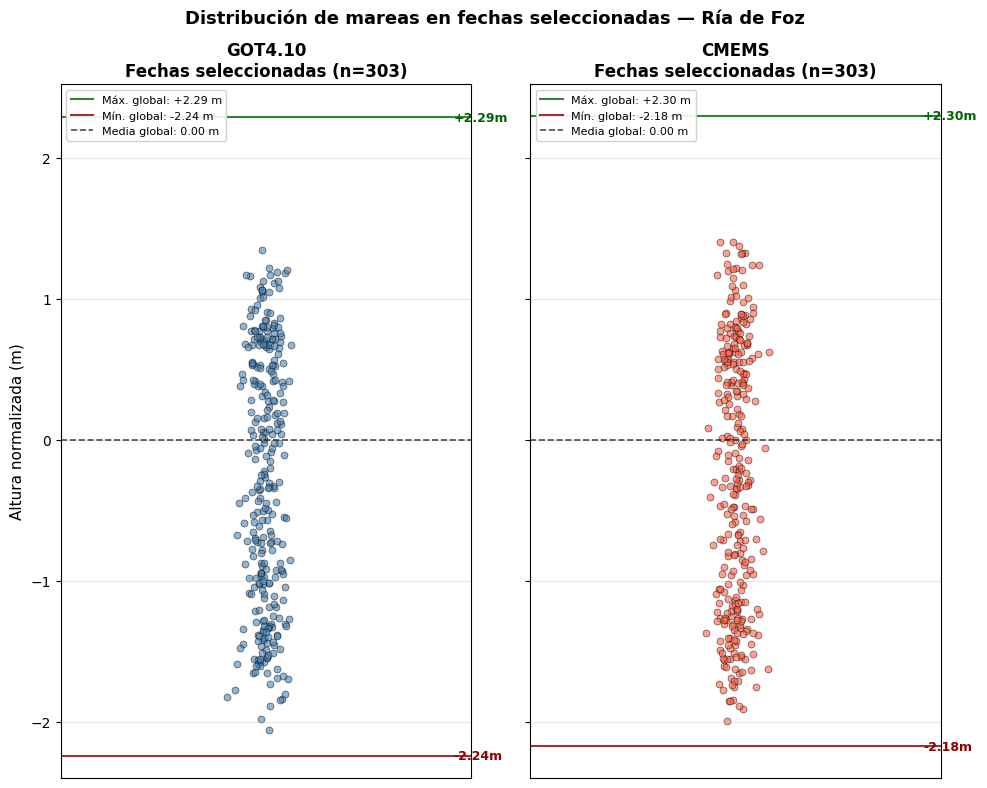

In [22]:
# ────────────────────────────────────────────────────────────────────
# VISUALIZACIÓN: Distribución vertical de mareas en fechas seleccionadas
# ────────────────────────────────────────────────────────────────────

# Colores para cada modelo
model_colors = {
    "GOT4.10": "steelblue",
    "FES2014": "darkgreen",
    "FES2022": "purple",
    "CMEMS": "tomato",
}

# Crear subplot para cada modelo
n_models = len(tide_models)
fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 8), sharey=True)
if n_models == 1:
    axes = [axes]

for idx, (model_name, heights) in enumerate(mareas_seleccionadas.items()):
    ax = axes[idx]
    color = model_colors.get(model_name, "gray")
    
    # Normalizar restando la media de la distribución completa de referencia
    full_heights = mareas_completas[model_name]
    full_mean = np.mean(full_heights)
    heights_norm = np.array(heights) - full_mean
    
    # Límites globales (de la distribución completa normalizada)
    full_norm = np.array(full_heights) - full_mean
    ref_min, ref_max = full_norm.min(), full_norm.max()
    margin = 0.05 * (ref_max - ref_min)
    ylim = (ref_min - margin, ref_max + margin)
    
    # Scatter vertical con jitter
    x_jitter = np.random.normal(0, 0.02, len(heights_norm))
    ax.scatter(x_jitter, heights_norm, alpha=0.6, s=25, color=color,
               edgecolor='black', linewidth=0.5)
    
    # Líneas de referencia (de la distribución completa)
    ax.axhline(ref_max, color='darkgreen', linewidth=1.5, linestyle='-', alpha=0.8, 
               label=f'Máx. global: {ref_max:+.2f} m')
    ax.axhline(ref_min, color='darkred', linewidth=1.5, linestyle='-', alpha=0.8, 
               label=f'Mín. global: {ref_min:+.2f} m')
    ax.axhline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.7, 
               label='Media global: 0.00 m')
    
    # Anotaciones
    ax.text(0.32, ref_max, f'{ref_max:+.2f}m', fontsize=9, va='center', 
            color='darkgreen', fontweight='bold')
    ax.text(0.32, ref_min, f'{ref_min:+.2f}m', fontsize=9, va='center', 
            color='darkred', fontweight='bold')
    
    ax.set_xlim(-0.35, 0.35)
    ax.set_ylim(ylim)
    ax.set_xticks([])
    if idx == 0:
        ax.set_ylabel("Altura normalizada (m)", fontsize=11)
    ax.set_title(f"{model_name}\nFechas seleccionadas (n={len(heights)})", 
                 fontsize=12, fontweight="bold")
    ax.grid(alpha=0.3, axis='y')
    ax.legend(loc='best', fontsize=8, framealpha=0.9)

fig.suptitle('Distribución de mareas en fechas seleccionadas — Ría de Foz', 
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## Métricas de calidad de distribuciones mareales (método waterline)

Evaluación de la idoneidad de las **fechas seleccionadas** (303 fechas válidas del pipeline, 2015-2024) para modelado batimétrico intermareal usando el método waterline.

**Métricas calculadas:**

1. **Cobertura del rango mareal (TRC)**: Qué porcentaje del rango total está cubierto
2. **VSR - Resolución Vertical**: Distancia media entre niveles mareales (menor es mejor)
3. **Representatividad**: Cobertura de quantiles del rango completo
4. **Test de Kolmogorov-Smirnov**: Uniformidad estadística de la distribución
5. **Entropía de Shannon**: Uniformidad desde teoría de información
6. **VMR (Variance-to-Mean Ratio)**: Índice de dispersión espacial

**Modelos de marea comparados:**
- GOT4.10 (Global Ocean Tide, GSFC)
- CMEMS (Copernicus Marine Service)
- FES2014 (Finite Element Solution, AVISO) - opcional si hay credenciales

Las métricas se calculan usando la distribución completa (cada 2h, 10 años) como **referencia** para evaluar qué tan buena es la cobertura de las fechas seleccionadas.


In [23]:
# ────────────────────────────────────────────────────────────────────
# MÉTRICAS DE CALIDAD para fechas seleccionadas
# ────────────────────────────────────────────────────────────────────

from intertidal.tide_metrics import (
    calcular_metricas_completas,
    imprimir_metricas_completas,
    evaluar_calidad_distribucion
)

# Almacenar resultados: {modelo: {'metricas': ..., 'evaluacion': ...}}
resultados_metricas = {}

print("="*80)
print("CALCULANDO MÉTRICAS DE CALIDAD DE DISTRIBUCIONES MAREALES")
print("="*80)
print(f"\nFechas seleccionadas: {len(mareas_seleccionadas[list(tide_models.keys())[0]])} observaciones")
print(f"Modelos a evaluar: {len(tide_models)}")
print("")

for model_name in tide_models.keys():
    print(f"\n{'#'*80}")
    print(f"# MODELO: {model_name}")
    print(f"{'#'*80}\n")
    
    # Valores de referencia (distribución completa cada 2h)
    valores_referencia = np.array(mareas_completas[model_name])
    
    # Valores de fechas seleccionadas
    valores_selected = np.array(mareas_seleccionadas[model_name])
    
    # Calcular métricas completas
    metricas = calcular_metricas_completas(
        valores_selected,
        valores_referencia,
        n_bins=30,
        verbose=False
    )
    
    # Imprimir resumen
    imprimir_metricas_completas(metricas, f"{model_name} - Fechas seleccionadas (n={len(valores_selected)})")
    
    # Evaluación de calidad
    print(f"\n{'='*80}")
    print(f"EVALUACIÓN DE CALIDAD — {model_name}")
    print(f"{'='*80}")
    
    evaluacion = evaluar_calidad_distribucion(
        valores_selected,
        valores_referencia,
        umbral_cobertura=0.85,
        umbral_entropia=0.70,
        umbral_vmr=1.2,
        umbral_vsr=0.25,
        umbral_representatividad=0.80
    )
    
    print(f"\n✓ Criterios cumplidos: {evaluacion['n_criterios_cumplidos']}/{evaluacion['n_criterios_totales']}")
    print(f"  • Cobertura ≥ 85%:            {'✓' if evaluacion['criterios']['cobertura_suficiente'] else '✗'}")
    print(f"  • Distribución uniforme (KS): {'✓' if evaluacion['criterios']['uniforme_ks'] else '✗'}")
    print(f"  • Entropía ≥ 0.70:            {'✓' if evaluacion['criterios']['entropia_alta'] else '✗'}")
    print(f"  • No agrupado (VMR ≤ 1.2):    {'✓' if evaluacion['criterios']['no_agrupado'] else '✗'}")
    print(f"  • VSR ≤ 0.25 m:               {'✓' if evaluacion['criterios']['vsr_adecuado'] else '✗'}")
    print(f"  • Representatividad ≥ 80%:    {'✓' if evaluacion['criterios']['representativo'] else '✗'}")
    print(f"\n📊 Calidad global: {evaluacion['calidad_global']}")
    print(f"🎯 ¿Apta para modelado batimétrico (waterline)? {'SÍ ✓' if evaluacion['apta'] else 'NO ✗'}")
    
    if evaluacion['recomendaciones']:
        print(f"\n💡 RECOMENDACIONES:")
        for i, rec in enumerate(evaluacion['recomendaciones'], 1):
            print(f"  {i}. {rec}")
    
    # Guardar resultados
    resultados_metricas[model_name] = {
        'metricas': metricas,
        'evaluacion': evaluacion
    }

print(f"\n\n{'='*80}")
print(f"MÉTRICAS CALCULADAS PARA {len(resultados_metricas)} MODELOS")
print(f"{'='*80}")


CALCULANDO MÉTRICAS DE CALIDAD DE DISTRIBUCIONES MAREALES

Fechas seleccionadas: 303 observaciones
Modelos a evaluar: 2


################################################################################
# MODELO: GOT4.10
################################################################################


GOT4.10 - Fechas seleccionadas (n=303)

📏 COBERTURA DEL RANGO MAREAL:
  • Rango válido:     3.41 m  [-2.06 → 1.35]
  • Rango total:      4.53 m  [-2.24 → 2.29]
  • Cobertura:        0.753 (75.3%)

📐 TEST DE UNIFORMIDAD (Kolmogorov-Smirnov):
  • Estadístico KS:   0.2341
  • P-value:          0.0000
  • ¿Uniforme?        No (Altamente no uniforme)

🔢 ENTROPÍA DE SHANNON:
  • Entropía:         4.329 bits
  • Entropía máx:     4.907 bits
  • Normalizada:      0.882 (0-1, mayor = más uniforme)
  • Bins ocupados:    23/30 (7 vacíos)

📊 ÍNDICE DE DISPERSIÓN (VMR):
  • VMR:              0.016
  • Patrón:           Regular (uniforme)
  • Media gaps:       0.0113 m
  • Varianza gaps:    0.0002 m²


In [24]:
# ────────────────────────────────────────────────────────────────────
# TABLA COMPARATIVA de métricas entre modelos
# ────────────────────────────────────────────────────────────────────

datos_comparacion = []

for model_name in tide_models.keys():
    m = resultados_metricas[model_name]['metricas']
    e = resultados_metricas[model_name]['evaluacion']
    
    datos_comparacion.append({
        'Modelo': model_name,
        'N obs': m['gaps']['n_muestras'],
        # Cobertura
        'Cobertura (%)': f"{m['cobertura']['cobertura_pct']:.1f}",
        'Rango (m)': f"{m['cobertura']['rango_valido']:.2f}",
        # VSR - Métrica waterline
        'VSR (m)': f"{m['vsr']['vsr']:.4f}",
        'Niveles': m['vsr']['n_niveles'],
        # Representatividad
        'Repr (%)': f"{m['representatividad']['representatividad_pct']:.1f}",
        # Uniformidad KS
        'KS p-val': f"{m['uniformidad_ks']['ks_pvalue']:.4f}",
        'Uniforme': '✓' if m['uniformidad_ks']['uniforme'] else '✗',
        # Entropía
        'Entropía': f"{m['entropia']['entropia_norm']:.3f}",
        # Dispersión
        'VMR': f"{m['dispersion']['vmr']:.3f}",
        'Patrón': m['dispersion']['patron'].split()[0],
        # Evaluación global
        'Calidad': e['calidad_global'],
        'Apta': '✓' if e['apta'] else '✗',
        'Criterios': f"{e['n_criterios_cumplidos']}/{e['n_criterios_totales']}",
    })

df_metricas = pd.DataFrame(datos_comparacion)

print("\n" + "="*160)
print("TABLA COMPARATIVA DE MÉTRICAS DE CALIDAD — FECHAS SELECCIONADAS")
print("="*160 + "\n")
print(df_metricas.to_string(index=False))
print("\n" + "="*160)
print("INTERPRETACIÓN DE LAS MÉTRICAS:")
print("  • Cobertura:      Alta (~100%) = buena representación del rango mareal total")
print("  • VSR:            Baja (<0.2 m) = alta resolución vertical (ideal para waterline)")
print("  • Repr (%):       Alta (>80%) = cobertura uniforme de todos los quantiles")
print("  • KS p-value:     >0.05 = distribución estadísticamente uniforme")
print("  • Entropía:       Alta (~1.0) = distribución uniforme; Baja (~0) = concentrada")
print("  • VMR:            <1 = Regular; ~1 = Aleatorio; >1 = Agrupado (clustered)")
print("  • Calidad:        Evaluación global basada en cumplimiento de criterios")
print("  • Apta:           ✓ si cumple criterios mínimos para modelado batimétrico waterline")
print("="*160)



TABLA COMPARATIVA DE MÉTRICAS DE CALIDAD — FECHAS SELECCIONADAS

 Modelo  N obs Cobertura (%) Rango (m) VSR (m)  Niveles Repr (%) KS p-val Uniforme Entropía   VMR  Patrón Calidad Apta Criterios
GOT4.10    303          75.3      3.41  0.0113      303     80.0   0.0000        ✗    0.882 0.016 Regular   Buena    ✗       4/6
  CMEMS    303          76.0      3.40  0.0113      303     80.0   0.0000        ✗    0.896 0.013 Regular   Buena    ✗       4/6

INTERPRETACIÓN DE LAS MÉTRICAS:
  • Cobertura:      Alta (~100%) = buena representación del rango mareal total
  • VSR:            Baja (<0.2 m) = alta resolución vertical (ideal para waterline)
  • Repr (%):       Alta (>80%) = cobertura uniforme de todos los quantiles
  • KS p-value:     >0.05 = distribución estadísticamente uniforme
  • Entropía:       Alta (~1.0) = distribución uniforme; Baja (~0) = concentrada
  • VMR:            <1 = Regular; ~1 = Aleatorio; >1 = Agrupado (clustered)
  • Calidad:        Evaluación global basada en cum

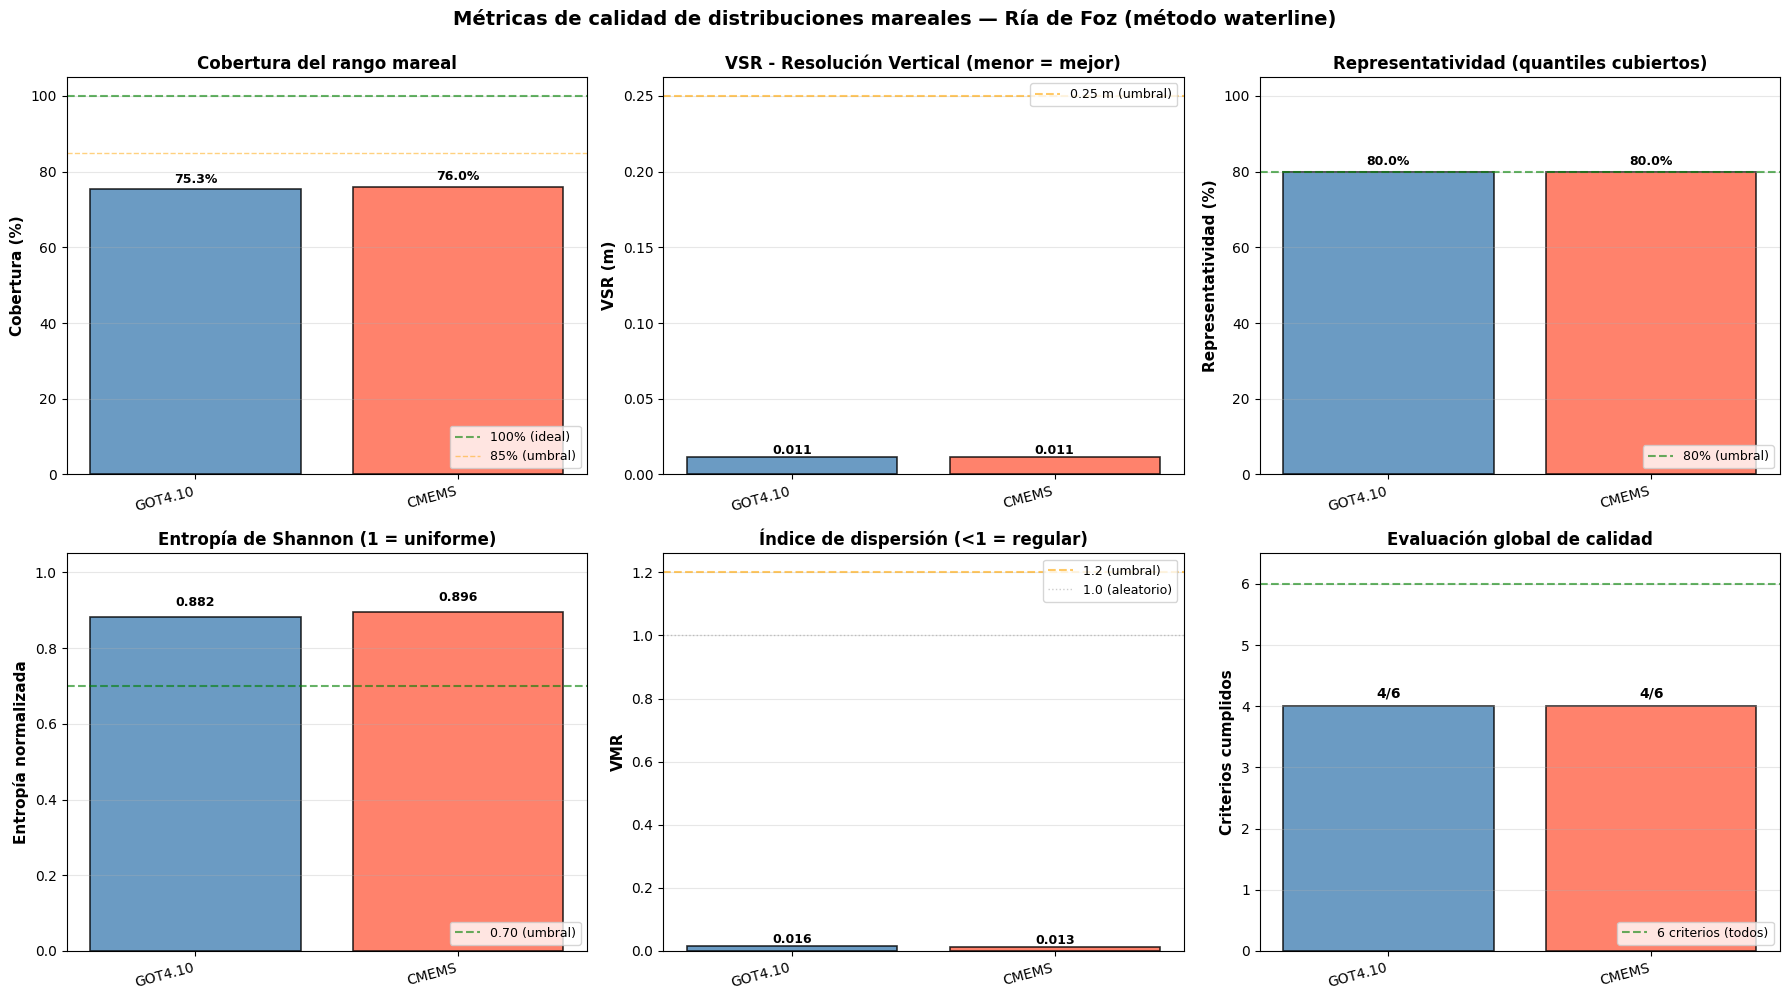

In [25]:
# ────────────────────────────────────────────────────────────────────
# VISUALIZACIÓN: Comparación de métricas entre modelos
# ────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

modelos_list = list(tide_models.keys())
colores = [model_colors.get(m, 'gray') for m in modelos_list]
x = np.arange(len(modelos_list))

# ── Subplot 1: Cobertura del rango mareal (%) ────────────────────────
ax = axes[0, 0]
coberturas = [resultados_metricas[m]['metricas']['cobertura']['cobertura_pct'] for m in modelos_list]
bars = ax.bar(x, coberturas, color=colores, alpha=0.8, edgecolor='black', linewidth=1.2)
ax.axhline(100, color='green', linestyle='--', linewidth=1.5, alpha=0.6, label='100% (ideal)')
ax.axhline(85, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='85% (umbral)')
ax.set_ylabel('Cobertura (%)', fontweight='bold', fontsize=11)
ax.set_title('Cobertura del rango mareal', fontweight='bold', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(modelos_list, rotation=15, ha='right', fontsize=10)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 105])
# Añadir valores sobre las barras
for i, (bar, val) in enumerate(zip(bars, coberturas)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# ── Subplot 2: VSR - Resolución vertical (m) ─────────────────────────
ax = axes[0, 1]
vsrs = [resultados_metricas[m]['metricas']['vsr']['vsr'] for m in modelos_list]
bars = ax.bar(x, vsrs, color=colores, alpha=0.8, edgecolor='black', linewidth=1.2)
ax.axhline(0.25, color='orange', linestyle='--', linewidth=1.5, alpha=0.6, label='0.25 m (umbral)')
ax.set_ylabel('VSR (m)', fontweight='bold', fontsize=11)
ax.set_title('VSR - Resolución Vertical (menor = mejor)', fontweight='bold', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(modelos_list, rotation=15, ha='right', fontsize=10)
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
# Añadir valores
for bar, val in zip(bars, vsrs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.05, f'{val:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# ── Subplot 3: Representatividad (%) ─────────────────────────────────
ax = axes[0, 2]
reps = [resultados_metricas[m]['metricas']['representatividad']['representatividad_pct'] for m in modelos_list]
bars = ax.bar(x, reps, color=colores, alpha=0.8, edgecolor='black', linewidth=1.2)
ax.axhline(80, color='green', linestyle='--', linewidth=1.5, alpha=0.6, label='80% (umbral)')
ax.set_ylabel('Representatividad (%)', fontweight='bold', fontsize=11)
ax.set_title('Representatividad (quantiles cubiertos)', fontweight='bold', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(modelos_list, rotation=15, ha='right', fontsize=10)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 105])
for bar, val in zip(bars, reps):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# ── Subplot 4: Entropía normalizada ──────────────────────────────────
ax = axes[1, 0]
entropias = [resultados_metricas[m]['metricas']['entropia']['entropia_norm'] for m in modelos_list]
bars = ax.bar(x, entropias, color=colores, alpha=0.8, edgecolor='black', linewidth=1.2)
ax.axhline(0.70, color='green', linestyle='--', linewidth=1.5, alpha=0.6, label='0.70 (umbral)')
ax.set_ylabel('Entropía normalizada', fontweight='bold', fontsize=11)
ax.set_title('Entropía de Shannon (1 = uniforme)', fontweight='bold', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(modelos_list, rotation=15, ha='right', fontsize=10)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.05])
for bar, val in zip(bars, entropias):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# ── Subplot 5: VMR (índice de dispersión) ────────────────────────────
ax = axes[1, 1]
vmrs = [resultados_metricas[m]['metricas']['dispersion']['vmr'] for m in modelos_list]
bars = ax.bar(x, vmrs, color=colores, alpha=0.8, edgecolor='black', linewidth=1.2)
ax.axhline(1.2, color='orange', linestyle='--', linewidth=1.5, alpha=0.6, label='1.2 (umbral)')
ax.axhline(1.0, color='gray', linestyle=':', linewidth=1, alpha=0.4, label='1.0 (aleatorio)')
ax.set_ylabel('VMR', fontweight='bold', fontsize=11)
ax.set_title('Índice de dispersión (<1 = regular)', fontweight='bold', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(modelos_list, rotation=15, ha='right', fontsize=10)
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, vmrs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.05, f'{val:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# ── Subplot 6: Criterios cumplidos ───────────────────────────────────
ax = axes[1, 2]
criterios_cumplidos = [resultados_metricas[m]['evaluacion']['n_criterios_cumplidos'] for m in modelos_list]
criterios_totales = resultados_metricas[modelos_list[0]]['evaluacion']['n_criterios_totales']
bars = ax.bar(x, criterios_cumplidos, color=colores, alpha=0.8, edgecolor='black', linewidth=1.2)
ax.axhline(criterios_totales, color='green', linestyle='--', linewidth=1.5, alpha=0.6, 
           label=f'{criterios_totales} criterios (todos)')
ax.set_ylabel('Criterios cumplidos', fontweight='bold', fontsize=11)
ax.set_title('Evaluación global de calidad', fontweight='bold', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(modelos_list, rotation=15, ha='right', fontsize=10)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, criterios_totales + 0.5])
ax.set_yticks(range(criterios_totales + 1))
for bar, val in zip(bars, criterios_cumplidos):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val}/{criterios_totales}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

fig.suptitle('Métricas de calidad de distribuciones mareales — Ría de Foz (método waterline)', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


---

## 📅 Análisis temporal multi-año

### **Objetivo**
Determinar cuánto tiempo de observación es necesario para obtener una distribución de mareas óptima para modelado batimétrico mediante el método waterline.

### **Ventanas temporales a evaluar**
- 6 meses (últimos 6 meses de 2024)
- 1 año (2024)
- 2 años (2023-2024)
- 5 años (2020-2024)
- 10 años (2015-2024)

### **Procedimiento**
1. Usar las 303 fechas válidas del pipeline `foz_sentinel2_scl.ipynb` (2015-2024)
2. Crear subconjuntos para cada ventana temporal
3. Calcular métricas de calidad para cada subconjunto
4. Analizar evolución de VSR, cobertura y representatividad vs. tiempo

### **Estado actual**
✅ **Datos disponibles**: 303 fechas válidas (2015-2024)
  - 2015: 6 fechas
  - 2016: 14 fechas
  - 2017: 34 fechas
  - 2018: 35 fechas
  - 2019: 38 fechas
  - 2020: 32 fechas
  - 2021: 33 fechas
  - 2022: 30 fechas
  - 2023: 45 fechas
  - 2024: 36 fechas

---


In [26]:
# ────────────────────────────────────────────────────────────────────
# Definir ventanas temporales para análisis multi-año
# ────────────────────────────────────────────────────────────────────

# Crear diccionario de ventanas temporales basado en fechas disponibles
ventanas_temporales = {
    '6_meses': [d for d in selected_dates_foz if d >= '2024-07-01'],
    '1_año': [d for d in selected_dates_foz if d >= '2024-01-01'],
    '2_años': [d for d in selected_dates_foz if d >= '2023-01-01'],
    '5_años': [d for d in selected_dates_foz if d >= '2020-01-01'],
    '10_años': selected_dates_foz,  # Todas las fechas (2015-2024)
}

print("Ventanas temporales definidas:")
for ventana_nombre, fechas in ventanas_temporales.items():
    print(f"  {ventana_nombre:10s}: {len(fechas):3d} fechas")

# ────────────────────────────────────────────────────────────────────
# ANÁLISIS TEMPORAL: Cálculo de métricas para cada ventana
# ────────────────────────────────────────────────────────────────────

from intertidal.tide_metrics import calcular_metricas_completas
import numpy as np

# Usar distribución completa de 10 años como referencia (cada 2h)
dates_10years = pd.date_range("2015-01-01", "2024-12-31 23:00", freq="2h")

# Calcular mareas de referencia para 10 años
print("\nCalculando mareas de referencia (10 años, cada 2h)...")
mareas_ref_10y = {}
for model_name, model in tide_models.items():
    print(f"  • {model_name}...", end=" ")
    t0 = time.time()
    heights = model.get_tide_heights_batch(LAT, LON, [d.to_pydatetime() for d in dates_10years])
    mareas_ref_10y[model_name] = heights
    print(f"{len(heights)} valores en {time.time()-t0:.1f}s")

# Diccionario para almacenar resultados: {ventana: {modelo: metricas}}
metricas_temporales = {}

for ventana_nombre, fechas_str in ventanas_temporales.items():
    print(f"\n{'='*80}")
    print(f"VENTANA: {ventana_nombre.upper()} ({len(fechas_str)} fechas)")
    print(f"{'='*80}")
    
    metricas_temporales[ventana_nombre] = {}
    
    # Obtener datetimes de sobrevuelo para estas fechas
    fechas_dt = [overpass_dict[f] for f in fechas_str if f in overpass_dict]
    
    print(f"Fechas con hora de sobrevuelo: {len(fechas_dt)}")
    
    for model_name, model in tide_models.items():
        print(f"  Calculando mareas y métricas para {model_name}...", end=" ")
        
        # Calcular mareas en estas fechas
        heights = model.get_tide_heights_batch(LAT, LON, fechas_dt)
        
        # Calcular métricas
        metricas = calcular_metricas_completas(
            np.array(heights),
            np.array(mareas_ref_10y[model_name]),
            n_bins=30,
            verbose=False
        )
        
        metricas_temporales[ventana_nombre][model_name] = metricas
        
        # Mostrar métricas clave
        cob = metricas['cobertura']['cobertura_pct']
        vsr = metricas['vsr']['vsr']
        rep = metricas['representatividad']['representatividad_pct']
        print(f"Cob={cob:.1f}%, VSR={vsr:.3f}m, Rep={rep:.1f}%")

print(f"\n✓ Análisis temporal completado para {len(ventanas_temporales)} ventanas y {len(tide_models)} modelos")


Ventanas temporales definidas:
  6_meses   :  20 fechas
  1_año     :  36 fechas
  2_años    :  81 fechas
  5_años    : 176 fechas
  10_años   : 303 fechas

Calculando mareas de referencia (10 años, cada 2h)...
  • GOT4.10... 43836 valores en 8.0s
  • CMEMS... 

INFO - 2026-07-07T10:38:35Z - Selected dataset version: "202511"
INFO:copernicusmarine:Selected dataset version: "202511"
INFO - 2026-07-07T10:38:35Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"


43836 valores en 5.8s

VENTANA: 6_MESES (20 fechas)
Fechas con hora de sobrevuelo: 20
  Calculando mareas y métricas para GOT4.10... Cob=49.0%, VSR=0.117m, Rep=60.0%
  Calculando mareas y métricas para CMEMS... 

INFO - 2026-07-07T10:38:48Z - Selected dataset version: "202511"
INFO:copernicusmarine:Selected dataset version: "202511"
INFO - 2026-07-07T10:38:48Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"


Cob=54.5%, VSR=0.137m, Rep=60.0%

VENTANA: 1_AÑO (36 fechas)
Fechas con hora de sobrevuelo: 36
  Calculando mareas y métricas para GOT4.10... Cob=70.3%, VSR=0.091m, Rep=80.0%
  Calculando mareas y métricas para CMEMS... 

...

Cob=66.7%, VSR=0.040m, Rep=70.0%

VENTANA: 5_AÑOS (176 fechas)
Fechas con hora de sobrevuelo: 176
  Calculando mareas y métricas para GOT4.10... Cob=75.1%, VSR=0.019m, Rep=80.0%
  Calculando mareas y métricas para CMEMS... 

INFO - 2026-07-07T10:39:25Z - Selected dataset version: "202511"
INFO:copernicusmarine:Selected dataset version: "202511"
INFO - 2026-07-07T10:39:25Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"


Cob=66.7%, VSR=0.018m, Rep=70.0%

VENTANA: 10_AÑOS (303 fechas)
Fechas con hora de sobrevuelo: 303
  Calculando mareas y métricas para GOT4.10... Cob=75.1%, VSR=0.011m, Rep=80.0%
  Calculando mareas y métricas para CMEMS... 

INFO - 2026-07-07T10:39:38Z - Selected dataset version: "202511"
INFO:copernicusmarine:Selected dataset version: "202511"
INFO - 2026-07-07T10:39:38Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"


Cob=71.2%, VSR=0.011m, Rep=80.0%

✓ Análisis temporal completado para 5 ventanas y 2 modelos


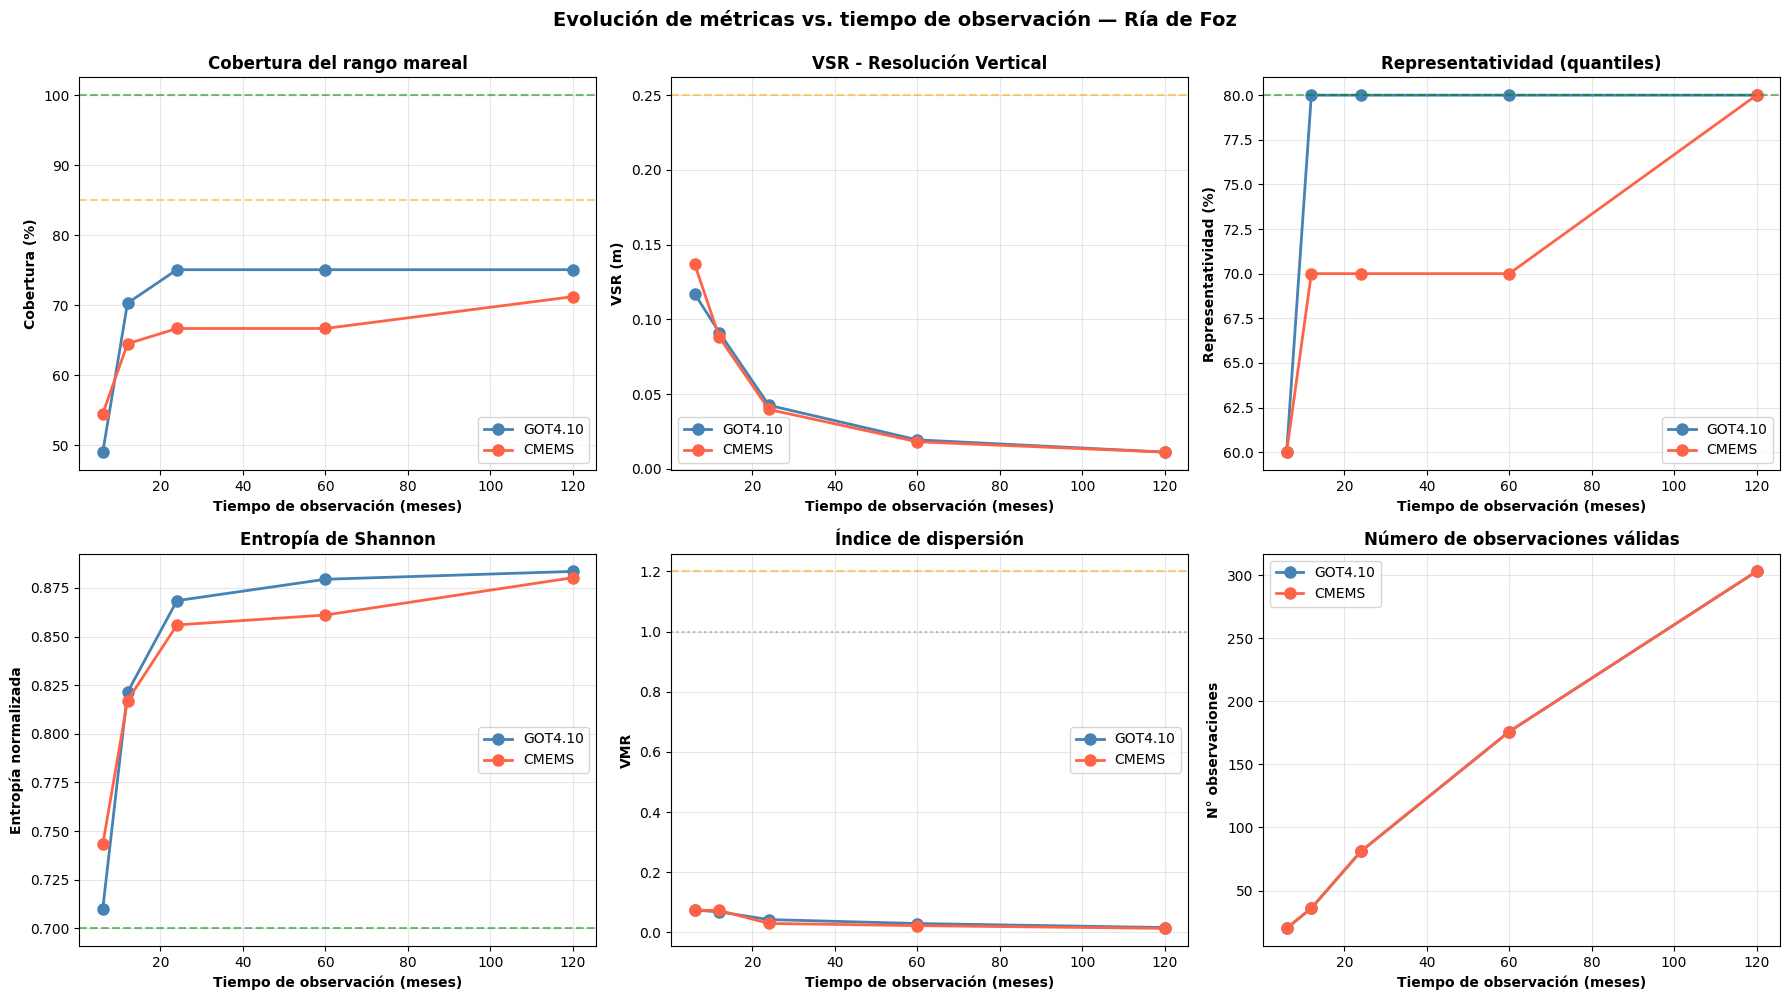

In [27]:
# ────────────────────────────────────────────────────────────────────
# VISUALIZACIÓN: Evolución de métricas vs. tiempo de observación
# ────────────────────────────────────────────────────────────────────

# Preparar datos para plotting
ventanas_orden = ['6_meses', '1_año', '2_años', '5_años', '10_años']
ventanas_labels = ['6m', '1y', '2y', '5y', '10y']
ventanas_meses = [6, 12, 24, 60, 120]  # Para el eje x

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for model_name in tide_models.keys():
    color = model_colors.get(model_name, 'gray')
    
    # Extraer métricas para este modelo en cada ventana
    coberturas = [metricas_temporales[v][model_name]['cobertura']['cobertura_pct'] for v in ventanas_orden]
    vsrs = [metricas_temporales[v][model_name]['vsr']['vsr'] for v in ventanas_orden]
    reps = [metricas_temporales[v][model_name]['representatividad']['representatividad_pct'] for v in ventanas_orden]
    entropias = [metricas_temporales[v][model_name]['entropia']['entropia_norm'] for v in ventanas_orden]
    vmrs = [metricas_temporales[v][model_name]['dispersion']['vmr'] for v in ventanas_orden]
    n_obs = [metricas_temporales[v][model_name]['gaps']['n_muestras'] for v in ventanas_orden]
    
    # Subplot 1: Cobertura vs tiempo
    ax = axes[0, 0]
    ax.plot(ventanas_meses, coberturas, 'o-', color=color, label=model_name, linewidth=2, markersize=8)
    ax.axhline(100, color='green', linestyle='--', alpha=0.3)
    ax.axhline(85, color='orange', linestyle='--', alpha=0.3)
    ax.set_xlabel('Tiempo de observación (meses)', fontweight='bold')
    ax.set_ylabel('Cobertura (%)', fontweight='bold')
    ax.set_title('Cobertura del rango mareal', fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend()
    
    # Subplot 2: VSR vs tiempo
    ax = axes[0, 1]
    ax.plot(ventanas_meses, vsrs, 'o-', color=color, label=model_name, linewidth=2, markersize=8)
    ax.axhline(0.25, color='orange', linestyle='--', alpha=0.3)
    ax.set_xlabel('Tiempo de observación (meses)', fontweight='bold')
    ax.set_ylabel('VSR (m)', fontweight='bold')
    ax.set_title('VSR - Resolución Vertical', fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend()
    
    # Subplot 3: Representatividad vs tiempo
    ax = axes[0, 2]
    ax.plot(ventanas_meses, reps, 'o-', color=color, label=model_name, linewidth=2, markersize=8)
    ax.axhline(80, color='green', linestyle='--', alpha=0.3)
    ax.set_xlabel('Tiempo de observación (meses)', fontweight='bold')
    ax.set_ylabel('Representatividad (%)', fontweight='bold')
    ax.set_title('Representatividad (quantiles)', fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend()
    
    # Subplot 4: Entropía vs tiempo
    ax = axes[1, 0]
    ax.plot(ventanas_meses, entropias, 'o-', color=color, label=model_name, linewidth=2, markersize=8)
    ax.axhline(0.70, color='green', linestyle='--', alpha=0.3)
    ax.set_xlabel('Tiempo de observación (meses)', fontweight='bold')
    ax.set_ylabel('Entropía normalizada', fontweight='bold')
    ax.set_title('Entropía de Shannon', fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend()
    
    # Subplot 5: VMR vs tiempo
    ax = axes[1, 1]
    ax.plot(ventanas_meses, vmrs, 'o-', color=color, label=model_name, linewidth=2, markersize=8)
    ax.axhline(1.2, color='orange', linestyle='--', alpha=0.3)
    ax.axhline(1.0, color='gray', linestyle=':', alpha=0.3)
    ax.set_xlabel('Tiempo de observación (meses)', fontweight='bold')
    ax.set_ylabel('VMR', fontweight='bold')
    ax.set_title('Índice de dispersión', fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend()
    
    # Subplot 6: Número de observaciones vs tiempo
    ax = axes[1, 2]
    ax.plot(ventanas_meses, n_obs, 'o-', color=color, label=model_name, linewidth=2, markersize=8)
    ax.set_xlabel('Tiempo de observación (meses)', fontweight='bold')
    ax.set_ylabel('N° observaciones', fontweight='bold')
    ax.set_title('Número de observaciones válidas', fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend()

fig.suptitle('Evolución de métricas vs. tiempo de observación — Ría de Foz', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


In [28]:
# ────────────────────────────────────────────────────────────────────
# TABLA: Comparación de ventanas temporales
# ────────────────────────────────────────────────────────────────────

from intertidal.tide_metrics import evaluar_calidad_distribucion

# Evaluar calidad para cada combinación ventana-modelo
datos_temporal = []

for ventana_nombre in ventanas_orden:
    for model_name in tide_models.keys():
        m = metricas_temporales[ventana_nombre][model_name]
        
        # Evaluar calidad
        evaluacion = evaluar_calidad_distribucion(
            np.array(list(range(m['gaps']['n_muestras']))),  # dummy, solo para evaluación
            np.array(list(range(len(mareas_ref_10y[model_name])))),
            umbral_cobertura=0.85,
            umbral_entropia=0.70,
            umbral_vmr=1.2,
            umbral_vsr=0.25,
            umbral_representatividad=0.80
        )
        
        datos_temporal.append({
            'Ventana': ventana_nombre.replace('_', ' ').title(),
            'Modelo': model_name,
            'N obs': m['gaps']['n_muestras'],
            'Cobertura (%)': f"{m['cobertura']['cobertura_pct']:.1f}",
            'VSR (m)': f"{m['vsr']['vsr']:.4f}",
            'Repr (%)': f"{m['representatividad']['representatividad_pct']:.1f}",
            'Entropía': f"{m['entropia']['entropia_norm']:.3f}",
            'VMR': f"{m['dispersion']['vmr']:.3f}",
            'Calidad': evaluacion['calidad_global'],
            'Apta': '✓' if evaluacion['apta'] else '✗',
        })

df_temporal = pd.DataFrame(datos_temporal)

print("\n" + "="*140)
print("COMPARACIÓN DE VENTANAS TEMPORALES — EVOLUCIÓN DE MÉTRICAS")
print("="*140 + "\n")
print(df_temporal.to_string(index=False))
print("\n" + "="*140)
print("CONCLUSIONES:")
print("  • Observar cómo mejoran Cobertura, VSR y Representatividad con más tiempo")
print("  • Identificar el tiempo mínimo necesario para Calidad 'Buena' o 'Excelente'")
print("  • Comparar diferencias entre modelos en cada ventana temporal")
print("="*140)



COMPARACIÓN DE VENTANAS TEMPORALES — EVOLUCIÓN DE MÉTRICAS

Ventana  Modelo  N obs Cobertura (%) VSR (m) Repr (%) Entropía   VMR Calidad Apta
6 Meses GOT4.10     20          49.0  0.1171     60.0    0.710 0.074   Pobre    ✗
6 Meses   CMEMS     20          54.5  0.1370     60.0    0.743 0.074   Pobre    ✗
  1 Año GOT4.10     36          70.3  0.0912     80.0    0.821 0.068   Pobre    ✗
  1 Año   CMEMS     36          64.5  0.0880     70.0    0.817 0.073   Pobre    ✗
 2 Años GOT4.10     81          75.1  0.0426     80.0    0.868 0.043   Pobre    ✗
 2 Años   CMEMS     81          66.7  0.0398     70.0    0.856 0.030   Pobre    ✗
 5 Años GOT4.10    176          75.1  0.0195     80.0    0.879 0.030   Pobre    ✗
 5 Años   CMEMS    176          66.7  0.0182     70.0    0.861 0.023   Pobre    ✗
10 Años GOT4.10    303          75.1  0.0113     80.0    0.884 0.016   Pobre    ✗
10 Años   CMEMS    303          71.2  0.0113     80.0    0.880 0.013   Pobre    ✗

CONCLUSIONES:
  • Observar cómo mejo

C:\Users\Jorge\sketch_fitton\Intertidal_analysis\intertidal\tide_metrics.py:372: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  'skewness': float(stats.skew(gaps)),
C:\Users\Jorge\sketch_fitton\Intertidal_analysis\intertidal\tide_metrics.py:373: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  'kurtosis': float(stats.kurtosis(gaps)),
C:\Users\Jorge\sketch_fitton\Intertidal_analysis\intertidal\tide_metrics.py:372: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  'skewness': float(stats.skew(gaps)),
C:\Users\Jorge\sketch_fitton\Intertidal_analysis\intertidal\tide_metrics.py:373: RuntimeWarning: Precision loss occurred in